# Quality control analysis of TCR phenotypes
- This vignette performs descriptive analysis and quality control of derived TCR phenotypes in ./data/tcr_phenotype/

In [ ]:
library(tidyverse)
library(data.table)
library(DescTools)
library(entropy)
library(patchwork)
library(pdftools)
library(parallel)

## Read in data
- In ./data/tcr_phenotype/README.md, you can find a description of each TCR phenotype
- In ./code/GLIPH2 and ./code/tcr_phenotype you can find R and Bash scripts for generating the phenotypes

In [3]:
# TCR phenotypes
gliph.local_cdr3 <- read.table("./data/tcr_phenotype/cdr3_gliph2-local.txt.gz",header=T)
gliph_cdr3 <- read.table("./data/tcr_phenotype/cdr3_gliph2-global.txt.gz",header=T)
gliph_trbv.cdr3 <- read.table("./data/tcr_phenotype/cdr3-trbv_gliph2-global.txt.gz",header=T)
aa <- read.table("./data/tcr_phenotype/cdr3_aa.txt.gz",header=T)
cdr3 <- read.table("./data/tcr_phenotype/cdr3_seq.txt.gz",header=T)
trbv.cdr3 <- read.table("./data/tcr_phenotype/cdr3-trbv_seq.txt.gz",header=T)
trbv <- read.table("./data/tcr_phenotype/trbv.txt.gz",header=T)

# ImmunoSEQ covariates
cov <- read.table("./data/covariate/immunoSEQ.cov",header=T)
head(cov)

,Sample,primer_set,product_subtype,total_t_cells,sample_cells,total_rearrangements,productive_rearrangements,fraction_productive,total_templates,productive_templates,fraction_productive_of_cells,productive_clonality,sample_clonality,sample_entropy,productive_entropy,sample_simpson_clonality,productive_simpson_clonality
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10001,Human-TCRB-PD4x,Standard,34.84533,173,98,71,0.7200000,100,72,0.20135026,0.0012358063,0.0016408360,6.603856,6.142147,0.10198039,0.11947674
2,10002,Human-TCRB-PD4x,Standard,1173.49379,11270,1272,1034,0.7927677,2157,1710,0.10412908,0.0885689557,0.0950645953,9.332493,9.127090,0.08517885,0.09128054
3,10025,Human-TCRB-PD4x,Standard,310.68230,2814,629,478,0.7628032,742,566,0.11041015,0.0145589625,0.0129015967,9.176971,8.771279,0.04473906,0.05193264
4,10033,Human-TCRB-PD4x,Standard,356.29355,3620,698,555,0.8010403,769,616,0.09841205,0.0105491951,0.0088702431,9.363285,9.020174,0.04175447,0.04755136
5,10034,Human-TCRB-PD4x,Standard,597.83229,4308,1056,787,0.7574827,1303,987,0.13876762,0.0263057183,0.0213087611,9.830360,9.367153,0.04496685,0.05546592
6,10042,Human-TCRB-PD4x,Standard,47.72308,255,126,86,0.6850394,127,87,0.18691035,0.0009818713,0.0006224873,6.972937,6.419955,0.08943163,0.10843656


## CDR3 length distribution

L,%
<fct>,<dbl>
1,0.000
2,0.000
3,0.000
4,0.001
5,0.002
6,0.007
7,0.018
8,0.029
9,0.065


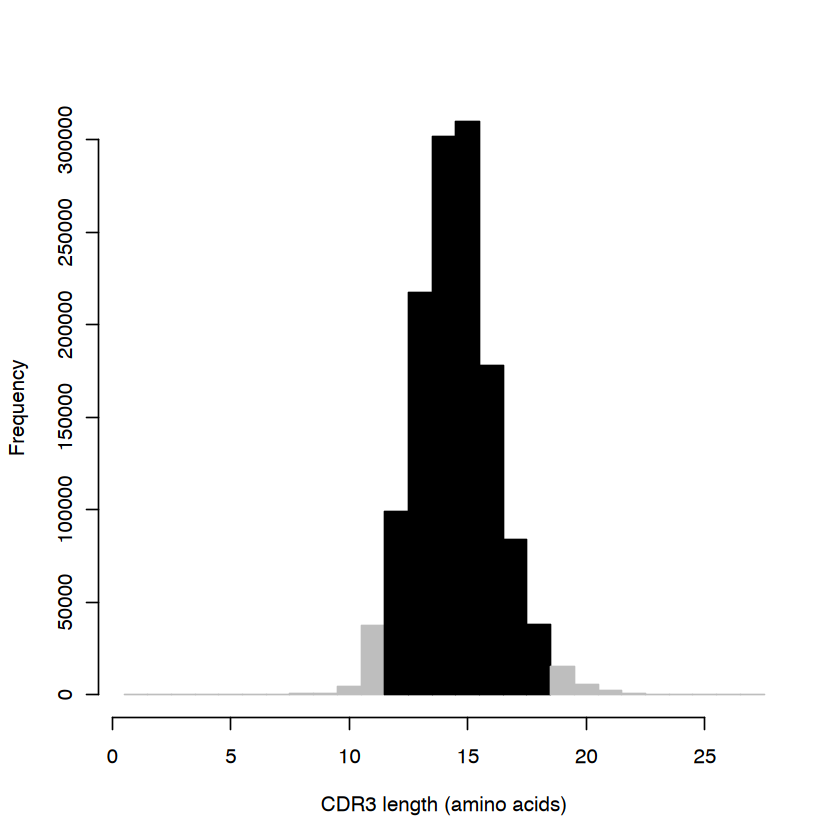

In [7]:
setDT(cdr3)
cdr3[, L := nchar(tcr)]

# Proportion
as.data.frame(prop.table(table(cdr3$L))) |>
  setNames(c("L","%")) |>
  transform(`%` = round(100 * `%`, 3)) # L12-L18 captures 95% of CDR3 sequences

# Histogram
h <- hist(cdr3$L,
          breaks = seq(min(cdr3$L, na.rm = TRUE) - 0.5,
                       max(cdr3$L, na.rm = TRUE) + 0.5,
                       by = 1),
          plot = FALSE)
cols <- ifelse(h$mids >= 12 & h$mids <= 18, "black", "grey")
plot(h,
     col = cols,
     border = cols,
     main = "",
     xlab = "CDR3 length (amino acids)")

## CDR3 IMGT positions
- One of the most complicated topics in TCR is the CDR3 **positioning definition**
- IMGT (https://www.imgt.org/IMGTrepertoire/) provides a standardised solution illustrated below;
- IMGT positions 106-117 in red were analysed in our project, as they directly contact peptide-HLA complex (PMID:35332318, doi: https://doi.org/10.1101/2025.10.27.683825) and carry sufficient diversity (see below)
- Numbers in the table are the CDR3 residue positions according to the IMGT definition;
- CDR3 with a 12-14 residue length have gaps in the middle; CDR3 with a 16-18 residue length have extra positions in the middle

In [8]:
browseURL(normalizePath("./vignettes/CDR3_IMGT_posmap.pdf"))

IRdisplay::display_html(
  sprintf('<a href="%s" target="_blank">Open PDF</a>',
          normalizePath("./vignettes/CDR3_IMGT_posmap.pdf", winslash="/"))
)

Open PDF

## CDR3 entropy and normalised mutual information (NMI)
- To characterise CDR3 sequence structure, we computed normalised entropy (amino acid diversity) and NMI (co-occurrence structures) between all pairs of positions
- Analyses were restricted to the dominant CDR3 length (L=15-mer) 
- As expected from V(D)J recombination, central CDR3 positions (IMGT 108-114) – which arise predominantly from non-templated nucleotide additions and junctional diversity – exhibit the highest entropy;
- In contrast, flanking positions (104-107 and 115-118) – which are largely encoded by germline V and J segments – show reduced entropy and high NMI reflecting structured constraints
- Notably, we observe strong and spatially localised high NMI within the central antigen-contact region (positions 108-114). This signal persists after collapsing clonal expansions (i.e., counting each unique CDR3 sequence once irrespective of template count), indicating that it is not driven by proliferative clonal dominance
- This pattern contrasts unselected peripheral blood repertoires (PMIDs: 35332318, 35177831), where central CDR3 positions show minimal NMI
- Together, these results indicate coordinated residue usage across CDR3 antigen-contacting sites in colorectal tumour-infiltrating T-cell repertoires, consistent with post-thymic selection;
- The restriction of these dependencies to the antigen-contact region is consistent with selective pressures on HLA–peptide–TCR recognition, potentially reflecting enrichment for TCR motifs recognising shared tumour antigens
- These observations motivated analyses of local CDR3 sequence motifs using GLIPH2 to identify convergent TCR antigen-recognition patterns

In [ ]:
# Script to compute sample-level Shannon entropy and NMI for CDR3
system("Rscript --vanilla ./code/tcr_phenotype/cdr3_aa_covariance.R") # NB: long run time

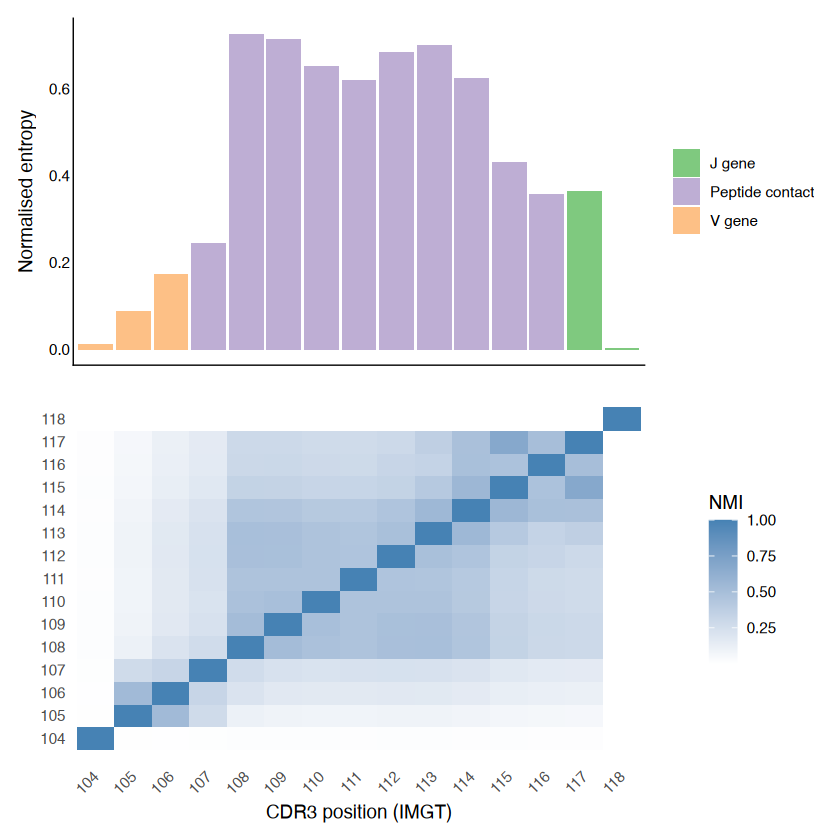

In [21]:
# Plot average across samples (template-weighted)
all_res <- readRDS("./data/tcr_phenotype/cdr3_covariance/cdr3_aa_covariance_weighted.rds")
setDT(all_res)
all_res <- all_res[
  , lapply(.SD, mean, na.rm = TRUE),
  by = .(i, k),
  .SDcols = c("MI", "Hx", "Hy", "NMI")
]
all_res[, pos_group := fifelse(
  i %between% c(104, 106), "V gene",
  fifelse(
    i %between% c(107, 116), "Peptide contact",
    "J gene"
  )
)]
p1 <- ggplot(all_res, aes(x = factor(i), y = Hx/log2(20), fill = pos_group)) +
  geom_col(position = "identity") +
  scale_fill_brewer(palette = "Accent", name = NULL) +
  theme_classic() +
  labs(x = "", y = "Normalised entropy") +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = "right",
    axis.line.x = element_line(linewidth = 0.3),
    axis.line.y = element_line(linewidth = 0.3))
p2 <- ggplot(all_res, aes(x = factor(i), y = factor(k), fill = NMI)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  theme_minimal() +
  labs(x = "CDR3 position (IMGT)", y = "", fill = "NMI") +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 0.5, hjust = 1),
    axis.title.x = element_text(margin = margin(t = 10)),
    panel.grid = element_blank())
p1 / p2

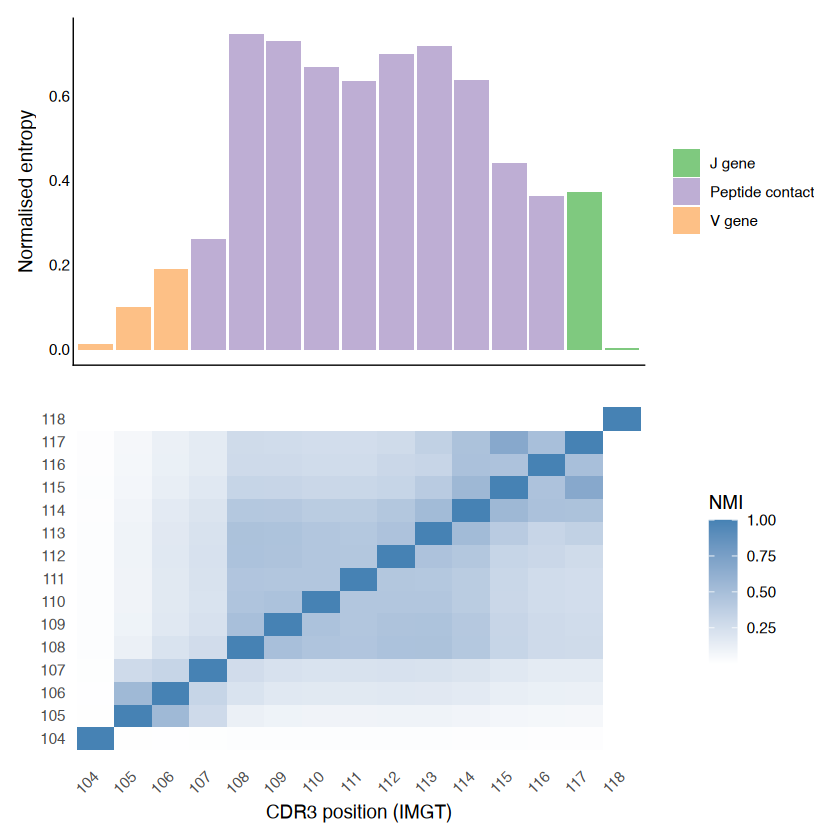

In [22]:
# Plot average across samples (unweighted)
all_res <- readRDS("./data/tcr_phenotype/cdr3_covariance/cdr3_aa_covariance_unweighted.rds")
setDT(all_res)
all_res <- all_res[
  , lapply(.SD, mean, na.rm = TRUE),
  by = .(i, k),
  .SDcols = c("MI", "Hx", "Hy", "NMI")
]
all_res[, pos_group := fifelse(
  i %between% c(104, 106), "V gene",
  fifelse(
    i %between% c(107, 116), "Peptide contact",
    "J gene"
  )
)]
p1 <- ggplot(all_res, aes(x = factor(i), y = Hx/log2(20), fill = pos_group)) +
  geom_col(position = "identity") +
  scale_fill_brewer(palette = "Accent", name = NULL) +
  theme_classic() +
  labs(x = "", y = "Normalised entropy") +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = "right",
    axis.line.x = element_line(linewidth = 0.3),
    axis.line.y = element_line(linewidth = 0.3))
p2 <- ggplot(all_res, aes(x = factor(i), y = factor(k), fill = NMI)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  theme_minimal() +
  labs(x = "CDR3 position (IMGT)", y = "", fill = "NMI") +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 0.5, hjust = 1),
    axis.title.x = element_text(margin = margin(t = 10)),
    panel.grid = element_blank())
p1 / p2

## TCR feature prevalence
- We quantified the prevalence of unique TCR features across the MECC cohort (N=2,750)
- Based on these distributions, we modelled CDR3-L-P-R (position-specific amino acid frequencies) and TRBV family usage as quantitative traits, restricted to features present in ≥20% of samples
- All other features were treated as binary traits, restricted to 'public' features present in ≥1% of samples

In [7]:
# Compute prevalence
calc_pe <- function(dt, group_var) {
  setDT(dt)
  n_samples <- uniqueN(dt$Sample)
  dt[
    ,
    .(pe = uniqueN(Sample) / n_samples),
    by = group_var
  ]
}
gliph.local_cdr3_pe <- calc_pe(gliph.local_cdr3,"tcr")
gliph_cdr3_pe <- calc_pe(gliph_cdr3,"tcr")
gliph_trbv.cdr3_pe <- calc_pe(gliph_trbv.cdr3,"tcr")
aa_pe <- calc_pe(aa,"tcr")
cdr3_pe <- calc_pe(cdr3,"tcr")
trbv.cdr3_pe <- calc_pe(trbv.cdr3,"tcr")
trbv_pe <- calc_pe(trbv,"tcr")

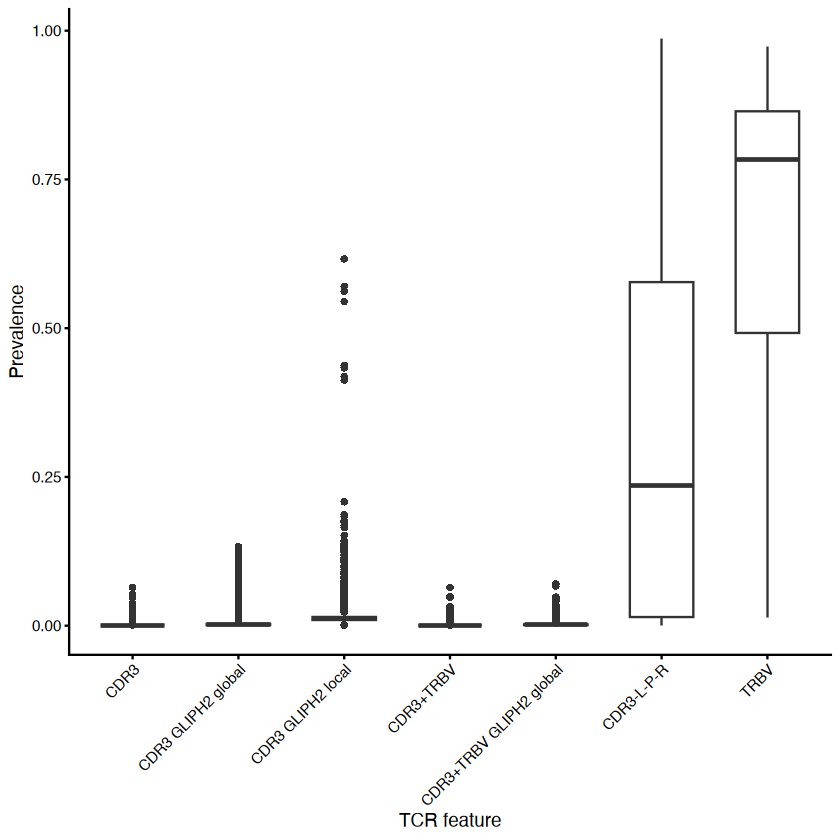

In [8]:
# Plot
all_pe <- rbindlist(list(
  aa_pe               [, .(Feature = "CDR3-L-P-R", pe)],
  cdr3_pe            [, .(Feature = "CDR3", pe)],
  trbv.cdr3_pe       [, .(Feature = "CDR3+TRBV", pe)],
  trbv_pe       [, .(Feature = "TRBV", pe)],
  gliph.local_cdr3_pe       [, .(Feature = "CDR3 GLIPH2 local", pe)],
  gliph_cdr3_pe       [, .(Feature = "CDR3 GLIPH2 global", pe)],
  gliph_trbv.cdr3_pe       [, .(Feature = "CDR3+TRBV GLIPH2 global", pe)]
), use.names = TRUE)

ggplot(all_pe, aes(x = Feature, y = pe)) +
  geom_boxplot(outlier.shape = 16, width = 0.6) +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  ) +
  labs(x = "TCR feature", y = "Prevalence")

In [9]:
stats <- all_pe %>%
  group_by(Feature) %>%
  summarise(
    Count = n(),
    `Median prevalence` = median(pe, na.rm = TRUE),
    Q1 = quantile(pe, 0.25, na.rm = TRUE),
    Q3 = quantile(pe, 0.75, na.rm = TRUE),
  ) %>%
  arrange(desc(`Median prevalence`))
print(stats)

# A tibble: 7 x 5
  Feature                   Count `Median prevalence`       Q1       Q3
  <chr>                     <int>               <dbl>    <dbl>    <dbl>
1 TRBV                         31            0.783    0.492    0.865   
2 CDR3-L-P-R                 2061            0.236    0.0145   0.577   
3 CDR3 GLIPH2 local          2656            0.0114   0.00956  0.0147  
4 CDR3 GLIPH2 global       168565            0.00183  0.00110  0.00293 
5 CDR3+TRBV GLIPH2 global   55903            0.00150  0.00113  0.00226 
6 CDR3                    1123431            0.000364 0.000364 0.000364
7 CDR3+TRBV               1173849            0.000364 0.000364 0.000364


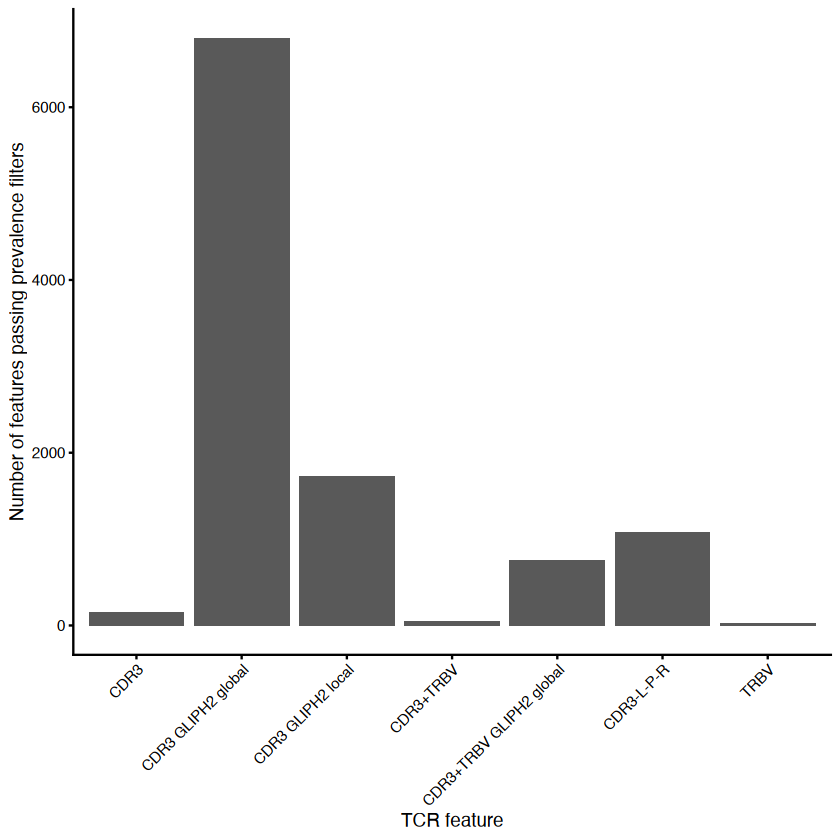

In [17]:
# Number of features passing prevalence QC (≥20% for quantitative and ≥1% for binary traits)
keep <- all_pe[
  (Feature %in% c("CDR3-L-P-R", "TRBV") & pe >= 0.2) |
  (!(Feature %in% c("CDR3-L-P-R", "TRBV")) & pe >= 0.01)
]
ggplot(keep, aes(x = Feature, y = after_stat(count))) +
  geom_bar(stat = "count") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  ) +
  labs(x = "TCR feature", y = "Number of features passing prevalence filters")

In [18]:
keep[, .N, by = Feature][order(-N)]

Feature,N
<chr>,<int>
CDR3 GLIPH2 global,6796
CDR3 GLIPH2 local,1730
CDR3-L-P-R,1078
CDR3+TRBV GLIPH2 global,756
CDR3,153
CDR3+TRBV,42
TRBV,26


## Feature count distibution
- Number of unique TCR features per colorectal cancer case

In [26]:
# Compute
calc_counts <- function(dt, group_var) {
  setDT(dt)
  dt[
    ,
    .(n_unique = uniqueN(get(group_var))),
    by = Sample
  ]
}
gliph.local_cdr3_n <- calc_counts(gliph.local_cdr3,"tcr")
gliph_cdr3_n <- calc_counts(gliph_cdr3,"tcr")
gliph_trbv.cdr3_n <- calc_counts(gliph_trbv.cdr3,"tcr")
aa_n <- calc_counts(aa,"tcr")
cdr3_n <- calc_counts(cdr3,"tcr")
trbv.cdr3_n <- calc_counts(trbv.cdr3,"tcr")
trbv_n <- calc_counts(trbv,"tcr")

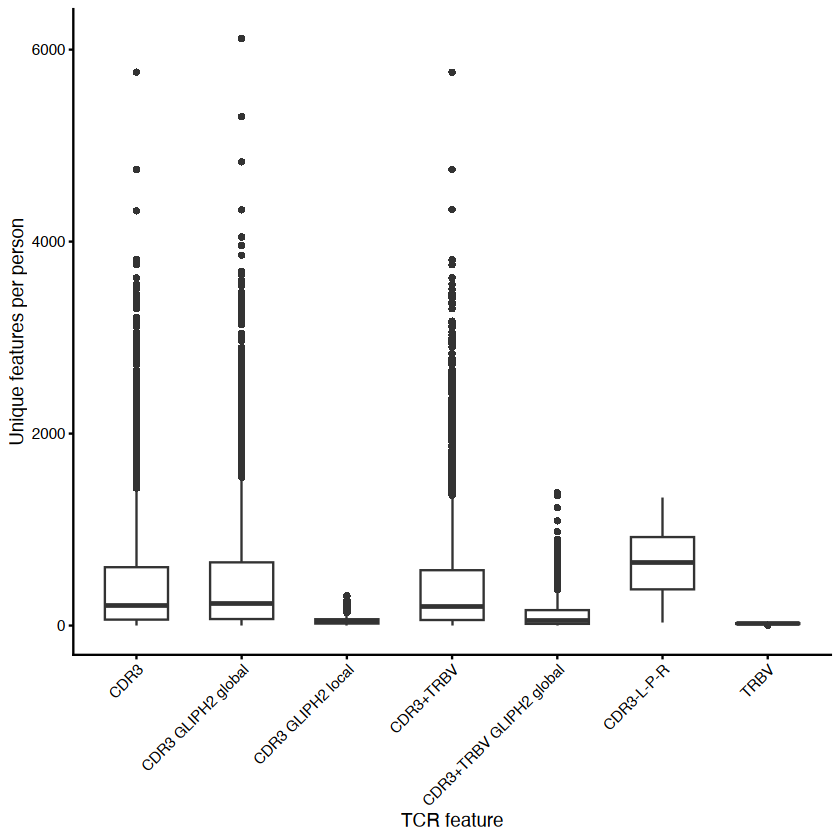

In [27]:
# Visualise
all_n <- rbindlist(list(
  aa_n               [, .(Feature = "CDR3-L-P-R", n_unique)],
  cdr3_n            [, .(Feature = "CDR3", n_unique)],
  trbv.cdr3_n       [, .(Feature = "CDR3+TRBV", n_unique)],
  trbv_n       [, .(Feature = "TRBV", n_unique)],
  gliph.local_cdr3_n       [, .(Feature = "CDR3 GLIPH2 local", n_unique)],
  gliph_cdr3_n       [, .(Feature = "CDR3 GLIPH2 global", n_unique)],
  gliph_trbv.cdr3_n       [, .(Feature = "CDR3+TRBV GLIPH2 global", n_unique)]
), use.names = TRUE)

ggplot(all_n, aes(x = Feature, y = n_unique)) +
  geom_boxplot(outlier.shape = 16, width = 0.6) +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  ) +
  labs(x = "TCR feature", y = "Unique features per person")

In [30]:
stats <- all_n %>%
  group_by(Feature) %>%
  summarise(
    `Median per sample` = median(n_unique, na.rm = TRUE),
    Q1 = quantile(n_unique, 0.25, na.rm = TRUE),
    Q3 = quantile(n_unique, 0.75, na.rm = TRUE),
  ) %>%
  arrange(desc(`Median per sample`))
print(stats)

# A tibble: 7 x 4
  Feature                 `Median per sample`    Q1    Q3
  <chr>                                 <dbl> <dbl> <dbl>
1 CDR3-L-P-R                             652.  377.  922 
2 CDR3 GLIPH2 global                     230    68   658.
3 CDR3                                   207    62   608 
4 CDR3+TRBV                              195    58   577.
5 CDR3+TRBV GLIPH2 global                 58    18   161 
6 CDR3 GLIPH2 local                       39    21    66 
7 TRBV                                    23    17    25 


## Influence of primer set on quantitative feature frequency
- We observed a strong influence for TCR features including TRBV family calls
- Primer set was included as a covariate in all analyses

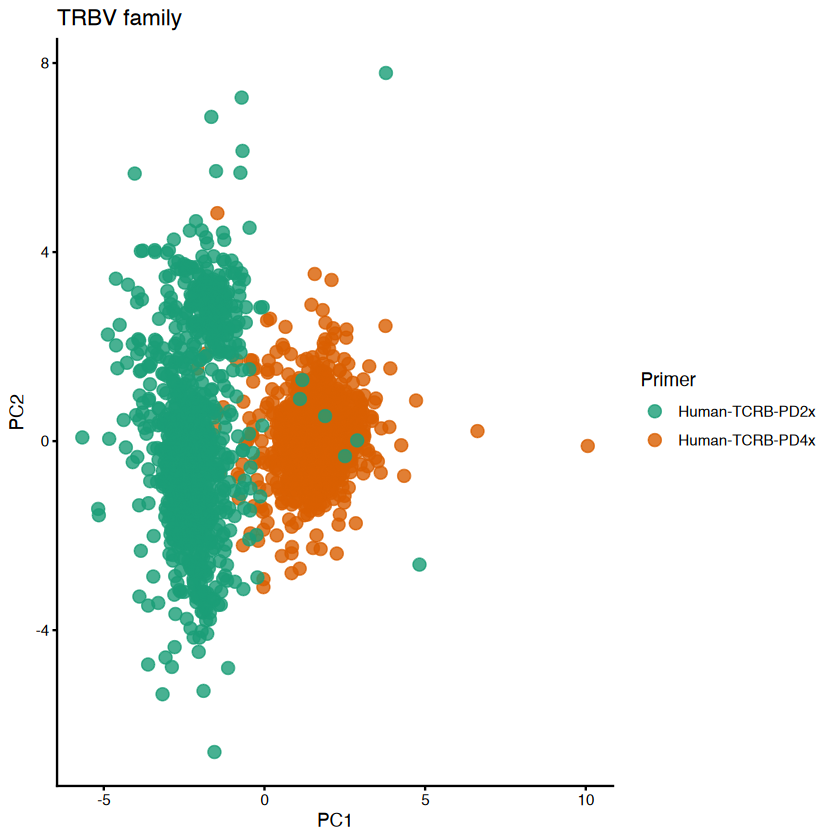

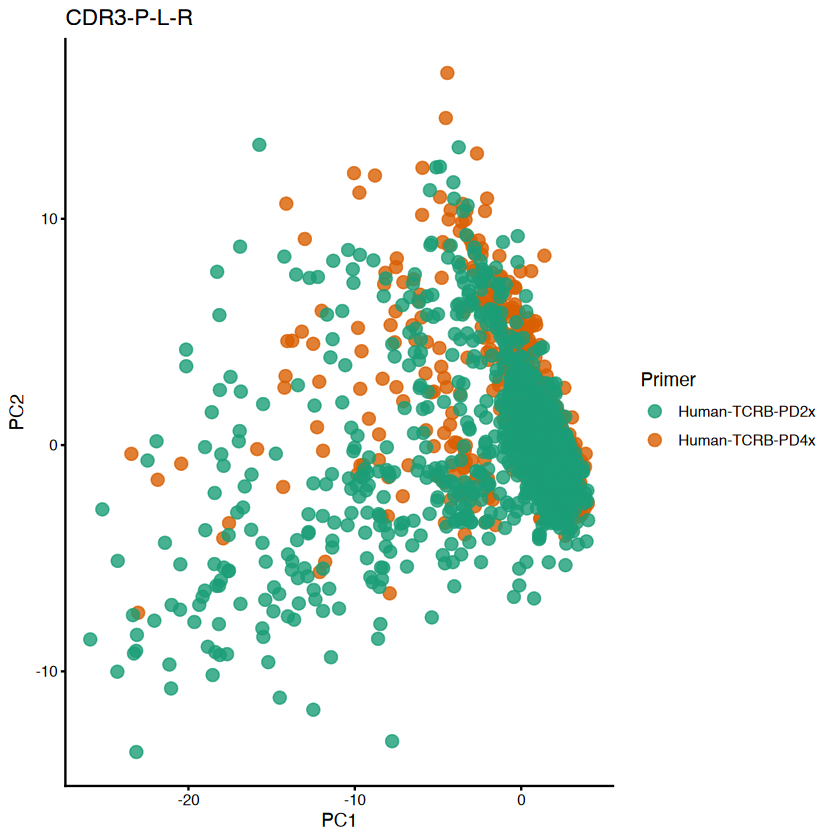

In [5]:
run_pca_plot <- function(df, cov, title, pe_filt = 0.2) {
  setDT(df)
  n_samp <- uniqueN(cov$Sample)
  keep <- df[, .(n_samp_cluster = uniqueN(Sample)),
             by = tcr][
               n_samp_cluster / n_samp >= pe_filt, tcr
             ]
  df <- df[tcr %in% keep]
  df <- df %>%
    pivot_wider(
      id_cols = Sample,
      names_from = tcr,
      values_from = rate,
      values_fill = 0
    )
  df <- cov %>%
    left_join(df, by = "Sample") %>%
    mutate(across(-Sample, ~replace_na(., 0)))
  tcrs_n <- setdiff(names(df), names(cov))
  X <- df %>%
    select(all_of(tcrs_n)) %>%
    as.data.frame()
  pca <- prcomp(X, center = TRUE, scale. = TRUE)
  pca_df <- data.frame(
    Sample = df$Sample,
    Primer = df$primer_set,
    PC1 = pca$x[,1],
    PC2 = pca$x[,2]
  )
  ggplot(pca_df, aes(PC1, PC2, color = Primer)) +
    geom_point(size = 3, alpha = 0.8) +
    scale_color_brewer(palette = "Dark2") +
    theme_classic() +
    ggtitle(title)
}

p <- run_pca_plot(trbv, cov, "TRBV family")
p
p <- run_pca_plot(aa, cov, "CDR3-P-L-R")
p

## Influence of primer set on binary feature calls
- Primer set was included as a covariate in all analyses

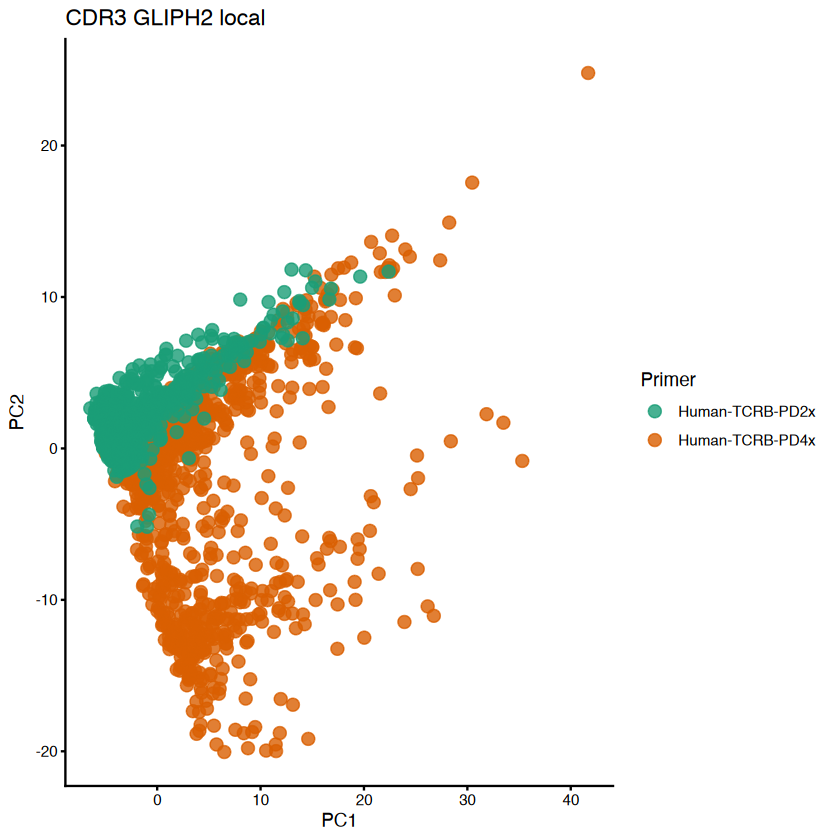

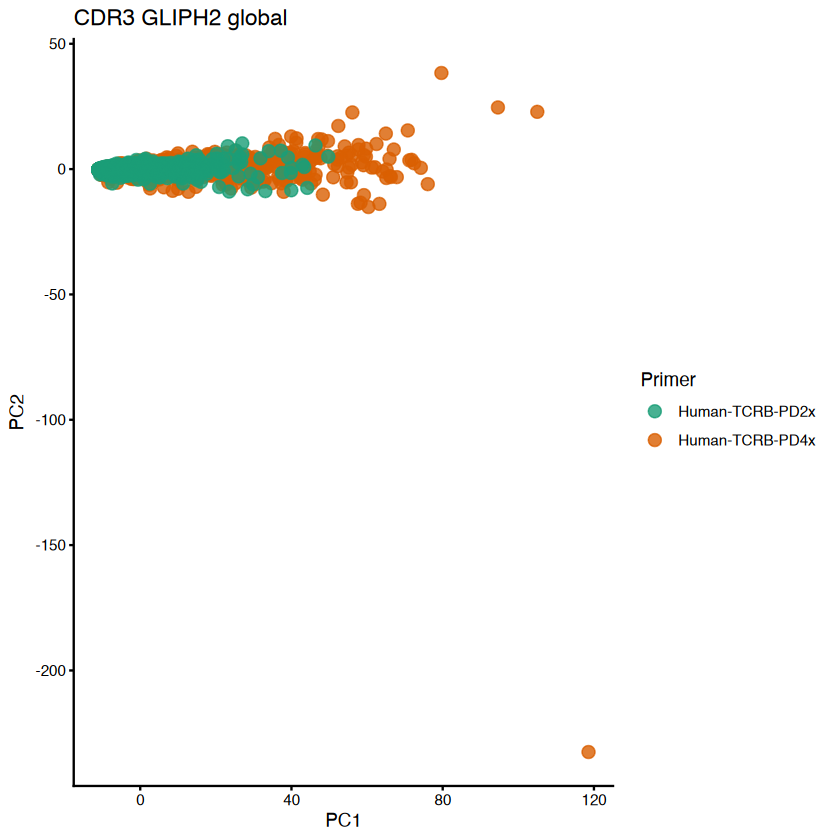

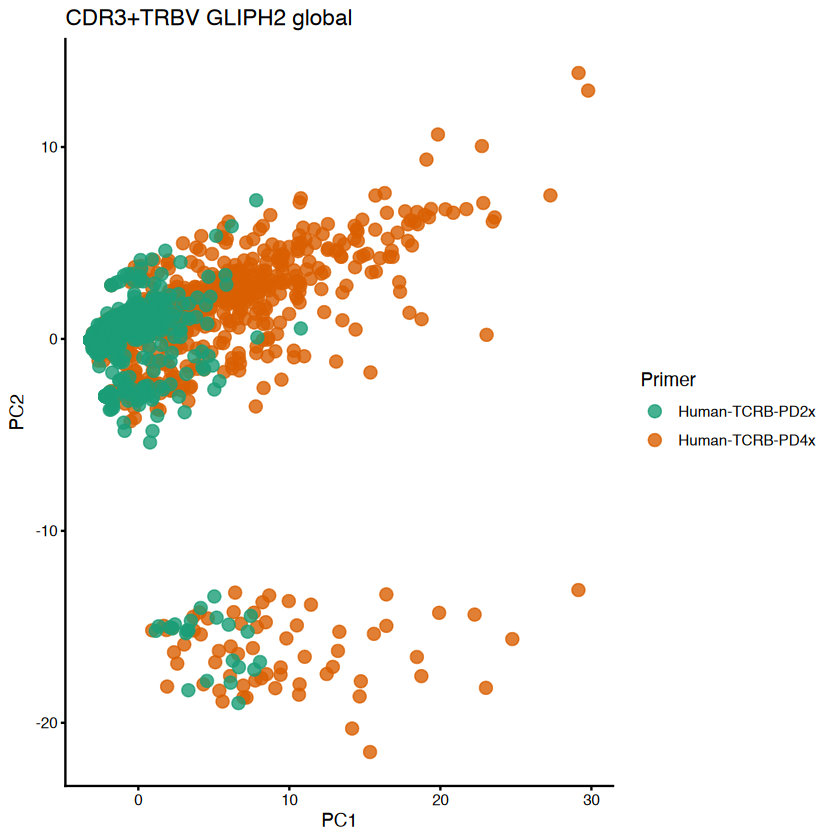

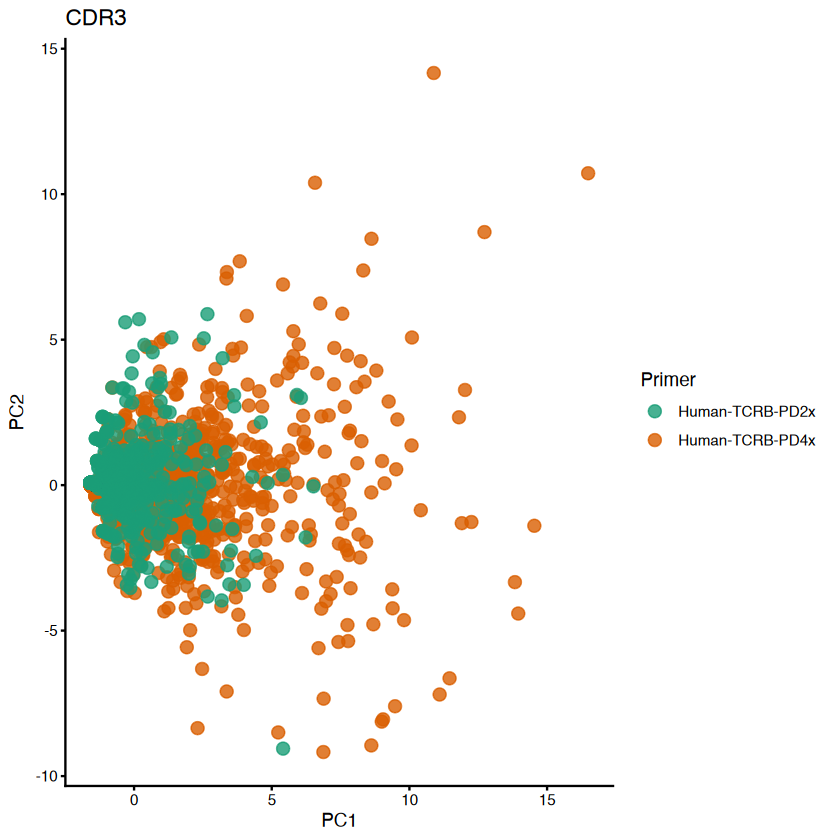

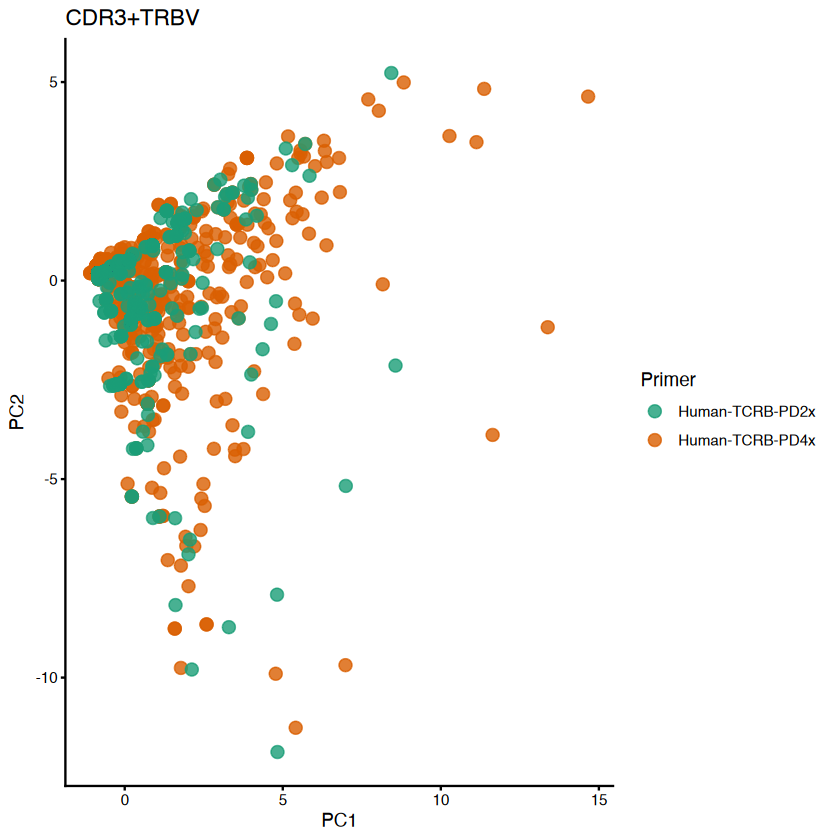

In [5]:
cdr3$L <- NULL

run_pca_plot <- function(df, cov, title, pe_filt = 0.01) {
  setDT(df)
  n_samp <- uniqueN(cov$Sample)
  keep <- df[, .(n_samp_cluster = uniqueN(Sample)),
             by = tcr][
               n_samp_cluster / n_samp >= pe_filt, tcr
             ]
  df <- df[tcr %in% keep]
  df <- df %>%
    pivot_wider(
      id_cols = Sample,
      names_from = tcr,
      values_from = rate,
      values_fill = 0,
      values_fn = function(x) 1
    )
  df <- cov %>%
    left_join(df, by = "Sample") %>%
    mutate(across(-Sample, ~replace_na(., 0)))
  tcrs_n <- setdiff(names(df), names(cov))
  X <- df %>%
    select(all_of(tcrs_n)) %>%
    as.data.frame()
  pca <- prcomp(X, center = TRUE, scale. = TRUE)
  pca_df <- data.frame(
    Sample = df$Sample,
    Primer = df$primer_set,
    PC1 = pca$x[,1],
    PC2 = pca$x[,2]
  )
  ggplot(pca_df, aes(PC1, PC2, color = Primer)) +
    geom_point(size = 3, alpha = 0.8) +
    scale_color_brewer(palette = "Dark2") +
    theme_classic() +
    ggtitle(title)
}

p <- run_pca_plot(gliph.local_cdr3, cov, "CDR3 GLIPH2 local")
p
p <- run_pca_plot(gliph_cdr3, cov, "CDR3 GLIPH2 global")
p
p <- run_pca_plot(gliph_trbv.cdr3, cov, "CDR3+TRBV GLIPH2 global")
p
p <- run_pca_plot(cdr3, cov, "CDR3")
p
p <- run_pca_plot(trbv.cdr3, cov, "CDR3+TRBV")
p